In [ ]:
!pip install torchview

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.optim as optim
from torchview import draw_graph
from tqdm import tqdm
from sklearn.preprocessing import MinMaxScaler, StandardScaler
from scipy.special import inv_boxcox
from scipy.stats import boxcox
from sklearn.metrics import (
    mean_absolute_percentage_error,
    root_mean_squared_error,
    mean_absolute_error,
)

In [ ]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"{device=}")

device='cuda'


In [ ]:
dataset = pd.read_csv("/content/train_val_1995-2018.csv")
dataset = dataset.drop(columns=["Unnamed: 0"])
dataset['datetime'] = pd.to_datetime(
    dataset['Year'].astype(str) + '-' +
    dataset['Decimal Day'].astype(str) +
    ' ' +
    dataset['Hour'].astype(str),
    format='%Y-%j %H'
)
dataset = dataset.drop(columns=["Year", "Decimal Day", "Hour"])
cols = ['datetime'] + [col for col in dataset.columns if col != 'datetime']
dataset = dataset[cols]
dataset.head()

,datetime,Bz_GSM,By_GSM,Bx_GSE,Kp,f10.7,AL,AU,T_proton,Np_density,V_plasma,V_Long_GSE,V_Lat_GSE,Dst,AE
0,1995-01-01 00:00:00,-1.2,3.6,-0.6,10,72.9,-6,25,15816.0,16.3,315.0,-0.4,4.6,-2,32
1,1995-01-01 01:00:00,-0.7,2.6,-0.9,10,72.9,-11,26,15601.0,18.8,315.0,-0.1,3.1,3,38
2,1995-01-01 02:00:00,0.0,1.8,0.5,10,72.9,-12,20,20703.0,19.3,320.0,0.3,2.1,6,34
3,1995-01-01 03:00:00,0.7,2.4,-3.2,0,72.9,-11,24,25094.0,16.4,317.0,1.6,2.2,5,36
4,1995-01-01 04:00:00,0.5,2.1,-4.3,0,72.9,-10,19,25604.0,14.5,313.0,1.7,2.2,3,31


In [ ]:
fill_values = {
    "Bz_GSM": 999.9,
    "By_GSM": 999.9,
    "Bx_GSE": 999.9,
    "Kp": 99,
    "f10.7": 999.9,
    "AL": 99999,
    "AU": 99999,
    "T_proton": 9999999.,
    "Np_density": 999.9,
    "V_plasma": 9999.,
    "V_Long_GSE": 999.9,
    "V_Lat_GSE": 999.9,
    "Dst": 99999,
    "AE": 9999,
}
for col in dataset.drop(columns=["datetime"]).columns:
    dataset[col] = dataset[col].replace(fill_values[col], np.nan)

In [ ]:
clean_dataset = dataset.copy()
features = [i for i in clean_dataset.columns if i != "datetime"]
clean_dataset[features] = clean_dataset[features].interpolate(method="pchip")
clean_dataset.head()

,datetime,Bz_GSM,By_GSM,Bx_GSE,Kp,f10.7,AL,AU,T_proton,Np_density,V_plasma,V_Long_GSE,V_Lat_GSE,Dst,AE
0,1995-01-01 00:00:00,-1.2,3.6,-0.6,10,72.9,-6,25,15816.0,16.3,315.0,-0.4,4.6,-2,32
1,1995-01-01 01:00:00,-0.7,2.6,-0.9,10,72.9,-11,26,15601.0,18.8,315.0,-0.1,3.1,3,38
2,1995-01-01 02:00:00,0.0,1.8,0.5,10,72.9,-12,20,20703.0,19.3,320.0,0.3,2.1,6,34
3,1995-01-01 03:00:00,0.7,2.4,-3.2,0,72.9,-11,24,25094.0,16.4,317.0,1.6,2.2,5,36
4,1995-01-01 04:00:00,0.5,2.1,-4.3,0,72.9,-10,19,25604.0,14.5,313.0,1.7,2.2,3,31


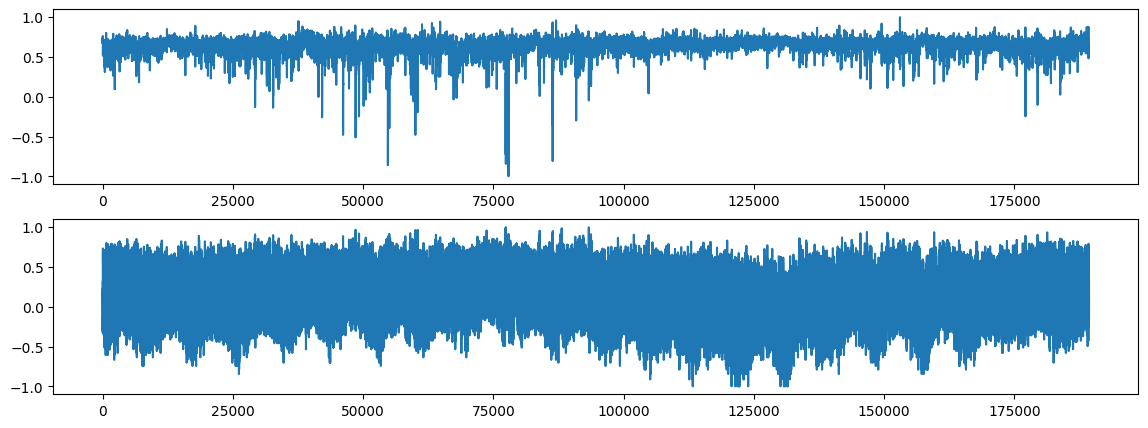

In [ ]:
dataset_to_preprocess = clean_dataset.copy()

lmbda = 0
ae_log_data = boxcox(dataset_to_preprocess["AE"].to_numpy(), lmbda)

dataset_to_preprocess["AE"] = ae_log_data
# 90% train, 10% test
train_size = int(len(dataset_to_preprocess) * 0.9)

train = dataset_to_preprocess.iloc[:train_size]
test = dataset_to_preprocess.iloc[train_size:]

X_train, y_train = train.drop(columns=["datetime", "Dst", "AE"]), train[["Dst", "AE"]]
X_test, y_test = test.drop(columns=["datetime", "Dst", "AE"]), test[["Dst", "AE"]]

X_scaler = StandardScaler()
X_train_scaled = X_scaler.fit_transform(X_train)
X_test_scaled = X_scaler.transform(X_test)

y_scaler = MinMaxScaler(feature_range=(-1, 1))
y_train_scaled = y_scaler.fit_transform(y_train)
y_test_scaled = y_scaler.transform(y_test)

_, axes = plt.subplots(2, 1, figsize=(14, 5))
axes[0].plot(y_train_scaled[:, 0])
axes[1].plot(y_train_scaled[:, 1])

In [ ]:
class GeomagneticDataset(torch.utils.data.Dataset):
    def __init__(
        self,
        X,
        y,
        X_window_size: int,
        y_window_size: int,
        stride: int = 1,
    ):
        self.X = torch.FloatTensor(X) if not isinstance(X, torch.Tensor) else X
        self.y = torch.FloatTensor(y) if not isinstance(y, torch.Tensor) else y
        self.X_window_size = X_window_size
        self.y_window_size = y_window_size
        self.stride = stride

        assert len(self.X) == len(self.y), "X and y must have same length"

        total_window = X_window_size + y_window_size
        self.num_samples = (len(self.X) - total_window) // stride + 1
        assert self.num_samples > 0, "Not enough data for windows"

    def __len__(self) -> int:
        return self.num_samples

    def __getitem__(self, index):
        start_idx = index * self.stride

        x_end_idx = start_idx + self.X_window_size
        x_window = self.X[start_idx:x_end_idx]

        y_start_idx = x_end_idx
        y_end_idx = y_start_idx + self.y_window_size
        y_window = self.y[y_start_idx:y_end_idx]  # [y_window_size, 2]

        return x_window, y_window

In [ ]:
X_window_size = 24*7  # 2 недели
y_window_size = 6
batch_size = 32
stride = y_window_size

train_dataset = GeomagneticDataset(
    X=X_train_scaled,
    y=y_train_scaled,
    X_window_size=X_window_size,
    y_window_size=y_window_size,
    stride=stride,
)
test_dataset = GeomagneticDataset(
    X=X_test_scaled,
    y=y_test_scaled,
    X_window_size=X_window_size,
    y_window_size=y_window_size,
    stride=stride,
)
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=batch_size, shuffle=False)
val_loader = torch.utils.data.DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

In [ ]:
class GeomagnetiсModel(nn.Module):
    def __init__(
        self,
        lstm_input_size: int,
        lstm_hidden_size: int,
        lstm_num_layers: int,
        lstm_dropout: float,
        attention_num_heads: int,
        forecasts_len: int,
        *args,
        **kwargs,
    ) -> None:
        super().__init__(*args, **kwargs)
        self.rnn_feature_extractor = nn.LSTM(
            input_size=lstm_input_size,
            hidden_size=lstm_hidden_size,
            num_layers=lstm_num_layers,
            dropout=lstm_dropout if lstm_num_layers > 1 else 0,
            batch_first=True,
        )
        self.attention = nn.MultiheadAttention(
            embed_dim=lstm_hidden_size,
            num_heads=attention_num_heads,
            dropout=lstm_dropout,
            batch_first=True,
        )
        self.attention_norm = nn.LayerNorm(lstm_hidden_size)
        self.dropout = nn.Dropout(lstm_dropout)
        heads_hidden_size = lstm_hidden_size * 2
        self.dst_head = nn.Sequential(
            nn.Linear(lstm_hidden_size, heads_hidden_size),
            nn.LeakyReLU(0.1),
            nn.Dropout(lstm_dropout),
            nn.Linear(heads_hidden_size, forecasts_len),
        )
        self.ae_head = nn.Sequential(
            nn.Linear(lstm_hidden_size, heads_hidden_size),
            nn.LeakyReLU(0.1),
            nn.Dropout(lstm_dropout),
            nn.Linear(heads_hidden_size, forecasts_len),
        )

    def forward(self, x):
        lstm_out, (_, _) = self.rnn_feature_extractor(x)
        attn_out, attn_weights = self.attention(lstm_out, lstm_out, lstm_out)
        lstm_out = self.attention_norm(lstm_out + attn_out)
        features = lstm_out[:, -1, :]
        features = self.dropout(features)
        dst = self.dst_head(features)
        ae = self.ae_head(features)

        return dst, ae, attn_weights

In [ ]:
class GeomagneticModelV2(nn.Module):
    def __init__(
        self,
        lstm_input_size: int,
        lstm_hidden_size: int,
        lstm_num_layers: int,
        lstm_dropout: float,
        attention_num_heads: int,
        forecasts_len: int,
        *args,
        **kwargs,
    ) -> None:
        super().__init__(*args, **kwargs)
        self.attention = nn.MultiheadAttention(
            embed_dim=lstm_input_size,
            num_heads=attention_num_heads,
            dropout=lstm_dropout,
            batch_first=True,
        )
        self.attention_norm = nn.LayerNorm(lstm_input_size)
        self.rnn_feature_extractor = nn.LSTM(
            input_size=lstm_input_size,
            hidden_size=lstm_hidden_size,
            num_layers=lstm_num_layers,
            dropout=lstm_dropout if lstm_num_layers > 1 else 0,
            batch_first=True,
        )
        self.dropout = nn.Dropout(lstm_dropout)

        heads_hidden_size = lstm_hidden_size * 2
        self.dst_head = nn.Sequential(
            nn.Linear(lstm_hidden_size, heads_hidden_size),
            nn.LeakyReLU(0.1),
            nn.Dropout(lstm_dropout),
            nn.Linear(heads_hidden_size, forecasts_len),
        )
        self.ae_head = nn.Sequential(
            nn.Linear(lstm_hidden_size, heads_hidden_size),
            nn.LeakyReLU(0.1),
            nn.Dropout(lstm_dropout),
            nn.Linear(heads_hidden_size, forecasts_len),
        )

    def forward(self, x):
        attn_out, attn_weights = self.attention(x, x, x)
        x = self.attention_norm(x + attn_out)
        lstm_out, _ = self.rnn_feature_extractor(x)
        features = lstm_out[:, -1, :]
        features = self.dropout(features)

        dst = self.dst_head(features)
        ae = self.ae_head(features)

        return dst, ae, attn_weights

Кол-во весов: 1599124


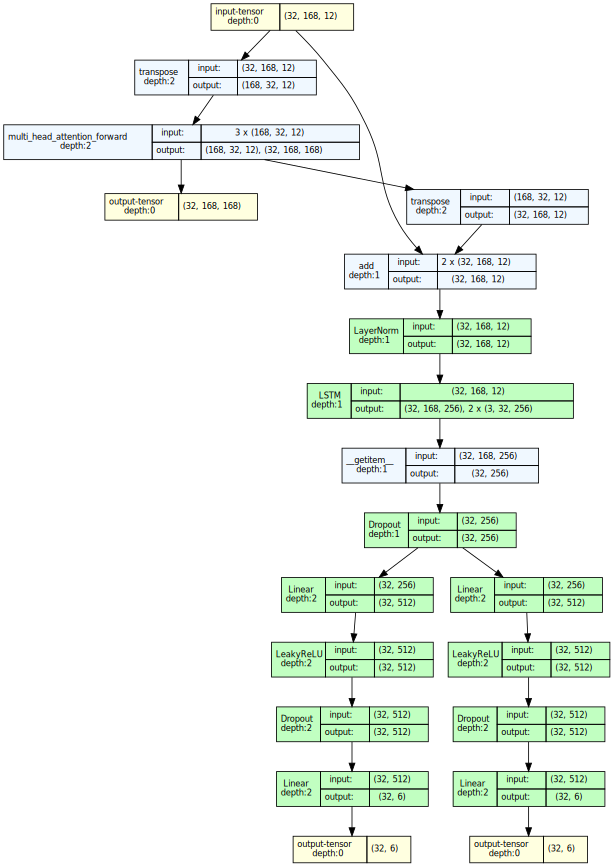

In [ ]:
initial_lr = 1e-3
EPOCHS = 150

lr_scheduler_factor = 0.5      # Умножаем lr на 0.5 при плато
lr_scheduler_patience = 10     # Ждем 10 эпох без улучшения
lr_scheduler_threshold = 1e-4  # Минимальное улучшение для сброса счетчика
lr_scheduler_cooldown = 5      # После снижения lr ждем 5 эпох
lr_scheduler_min_lr = 1e-6     # Минимальный lr

baseline_model = GeomagneticModelV2(
    lstm_input_size=12,
    lstm_hidden_size=256,
    lstm_num_layers=3,
    lstm_dropout=0.2,
    attention_num_heads=4,
    forecasts_len=y_window_size,
)

print(f"Кол-во весов: {sum([i.numel() for i in baseline_model.parameters()])}")
loss_fn = nn.MSELoss()
optimizer = optim.AdamW(baseline_model.parameters(), lr=initial_lr, weight_decay=0.01)
lr_scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=lr_scheduler_factor,
    patience=lr_scheduler_patience,
    threshold=lr_scheduler_threshold,
    cooldown=lr_scheduler_cooldown,
    min_lr=lr_scheduler_min_lr,
)
graph = draw_graph(baseline_model, input_size=[batch_size, X_window_size, 12])
graph.visual_graph

In [ ]:
patience_counter = 0
patience_delta = 1e-4
patience = 50

best_val_loss = float('inf')
best_epoch = 0

history_train = {
    "dst_loss": [],
    "ae_loss": [],
    "summary_loss": [],
    "ae": {"RMSE": [], "MAPE": [], "MAE": []},
    "dst": {"RMSE": [], "MAPE": [], "MAE": []}
}
history_val = {
    "loss": [],
    "ae": {"RMSE": [], "MAPE": [], "MAE": []},
    "dst": {"RMSE": [], "MAPE": [], "MAE": []}
}

baseline_model.to(device)

for e in range(EPOCHS):
    # ========== TRAIN ==========
    baseline_model.train()
    train_progress = tqdm(train_loader)
    running_history = {
        "dst_loss": [],
        "ae_loss": [],
        "summary_loss": [],
        "ae": {"RMSE": [], "MAPE": [], "MAE": []},
        "dst": {"RMSE": [], "MAPE": [], "MAE": []}
    }

    for x, y in train_progress:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()

        dst_y, ae_y = y[:, :, 0], y[:, :, 1]
        dst_y_pred, ae_y_pred, _ = baseline_model(x)

        dst_loss = loss_fn(dst_y_pred, dst_y)
        ae_loss = loss_fn(ae_y_pred, ae_y)
        loss = dst_loss + ae_loss

        loss.backward()
        optimizer.step()

        # Метрики для логирования
        with torch.no_grad():
            pred_data = np.stack([dst_y_pred.detach().cpu().numpy().flatten(),
                                 ae_y_pred.detach().cpu().numpy().flatten()], axis=1)
            label_data = np.stack([dst_y.detach().cpu().numpy().flatten(),
                                  ae_y.detach().cpu().numpy().flatten()], axis=1)
            pred_data = y_scaler.inverse_transform(pred_data)
            pred_data[:, 1] = inv_boxcox(pred_data[:, 1], lmbda)
            label_data = y_scaler.inverse_transform(label_data)
            label_data[:, 1] = inv_boxcox(label_data[:, 1], lmbda)

            dst_rmse = root_mean_squared_error(label_data[:, 0], pred_data[:, 0])
            ae_rmse = root_mean_squared_error(label_data[:, 1], pred_data[:, 1])
            dst_mape = mean_absolute_percentage_error(label_data[:, 0], pred_data[:, 0])
            ae_mape = mean_absolute_percentage_error(label_data[:, 1], pred_data[:, 1])
            dst_mae = mean_absolute_error(label_data[:, 0], pred_data[:, 0])
            ae_mae = mean_absolute_error(label_data[:, 1], pred_data[:, 1])

            running_history["dst"]["RMSE"].append(dst_rmse)
            running_history["ae"]["RMSE"].append(ae_rmse)
            running_history["dst"]["MAPE"].append(dst_mape)
            running_history["ae"]["MAPE"].append(ae_mape)
            running_history["dst"]["MAE"].append(dst_mae)
            running_history["ae"]["MAE"].append(ae_mae)
            running_history["dst_loss"].append(dst_loss.item())
            running_history["ae_loss"].append(ae_loss.item())
            running_history["summary_loss"].append(loss.item())

        train_progress.set_description(
            f"Epoch [{e+1:>3}/{EPOCHS}] [TRAIN] dst-RMSE {dst_rmse:.3f} ae-RMSE {ae_rmse:.3f} Loss {loss.item():.4f}"
        )

    history_train["dst"]["RMSE"].append(np.mean(running_history["dst"]["RMSE"]))
    history_train["ae"]["RMSE"].append(np.mean(running_history["ae"]["RMSE"]))
    history_train["dst"]["MAPE"].append(np.mean(running_history["dst"]["MAPE"]))
    history_train["ae"]["MAPE"].append(np.mean(running_history["ae"]["MAPE"]))
    history_train["dst"]["MAE"].append(np.mean(running_history["dst"]["MAE"]))
    history_train["ae"]["MAE"].append(np.mean(running_history["ae"]["MAE"]))
    history_train["dst_loss"].append(np.mean(running_history["dst_loss"]))
    history_train["ae_loss"].append(np.mean(running_history["ae_loss"]))
    history_train["summary_loss"].append(np.mean(running_history["summary_loss"]))

    # ========== VALIDATION ==========
    with torch.no_grad():
        baseline_model.eval()
        val_progress = tqdm(val_loader)
        running_val = {
            "loss": [],
            "ae": {"RMSE": [], "MAPE": [], "MAE": []},
            "dst": {"RMSE": [], "MAPE": [], "MAE": []}
        }

        for x, y in val_progress:
            x, y = x.to(device), y.to(device)
            dst_y, ae_y = y[:, :, 0], y[:, :, 1]
            dst_y_pred, ae_y_pred, _ = baseline_model(x)

            # Validation loss
            dst_loss = loss_fn(dst_y_pred, dst_y)
            ae_loss = loss_fn(ae_y_pred, ae_y)
            val_loss = dst_loss + ae_loss
            running_val["loss"].append(val_loss.item())

            # Метрики для логирования
            pred_data = np.stack([dst_y_pred.detach().cpu().numpy().flatten(),
                                 ae_y_pred.detach().cpu().numpy().flatten()], axis=1)
            label_data = np.stack([dst_y.detach().cpu().numpy().flatten(),
                                  ae_y.detach().cpu().numpy().flatten()], axis=1)
            pred_data = y_scaler.inverse_transform(pred_data)
            pred_data[:, 1] = inv_boxcox(pred_data[:, 1], lmbda)
            label_data = y_scaler.inverse_transform(label_data)
            label_data[:, 1] = inv_boxcox(label_data[:, 1], lmbda)

            dst_rmse = root_mean_squared_error(label_data[:, 0], pred_data[:, 0])
            ae_rmse = root_mean_squared_error(label_data[:, 1], pred_data[:, 1])
            dst_mape = mean_absolute_percentage_error(label_data[:, 0], pred_data[:, 0])
            ae_mape = mean_absolute_percentage_error(label_data[:, 1], pred_data[:, 1])
            dst_mae = mean_absolute_error(label_data[:, 0], pred_data[:, 0])
            ae_mae = mean_absolute_error(label_data[:, 1], pred_data[:, 1])

            running_val["dst"]["RMSE"].append(dst_rmse)
            running_val["ae"]["RMSE"].append(ae_rmse)
            running_val["dst"]["MAPE"].append(dst_mape)
            running_val["ae"]["MAPE"].append(ae_mape)
            running_val["dst"]["MAE"].append(dst_mae)
            running_val["ae"]["MAE"].append(ae_mae)

            val_progress.set_description(
                f"Epoch [{e+1:>3}/{EPOCHS}] [VAL  ] dst-RMSE {dst_rmse:.3f} ae-RMSE {ae_rmse:.3f} Loss {val_loss.item():.4f}"
            )
        current_val_loss = np.mean(running_val["loss"])
        history_val["loss"].append(current_val_loss)
        history_val["dst"]["RMSE"].append(np.mean(running_val["dst"]["RMSE"]))
        history_val["ae"]["RMSE"].append(np.mean(running_val["ae"]["RMSE"]))
        history_val["dst"]["MAPE"].append(np.mean(running_val["dst"]["MAPE"]))
        history_val["ae"]["MAPE"].append(np.mean(running_val["ae"]["MAPE"]))
        history_val["dst"]["MAE"].append(np.mean(running_val["dst"]["MAE"]))
        history_val["ae"]["MAE"].append(np.mean(running_val["ae"]["MAE"]))
    lr_scheduler.step(metrics=current_val_loss)
    if current_val_loss < best_val_loss - patience_delta:
        best_val_loss = current_val_loss
        best_epoch = e + 1
        torch.save({
            'epoch': best_epoch,
            'model_state_dict': baseline_model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'val_loss': best_val_loss,
            'val_metrics': {
                'dst_rmse': history_val["dst"]["RMSE"][-1],
                'ae_rmse': history_val["ae"]["RMSE"][-1],
            }
        }, f"./best_model_epoch_{best_epoch}.pt")
        patience_counter = 0
        print(f"New best model! Epoch {best_epoch}, Val Loss: {best_val_loss:.6f}")
        print(f"Val DST RMSE: {history_val['dst']['RMSE'][-1]:.3f}, AE RMSE: {history_val['ae']['RMSE'][-1]:.3f}")
    else:
        patience_counter += 1
    if patience_counter >= patience:
        print(f"Early stopping triggered at epoch {e+1}")
        print(f"Best model was at epoch {best_epoch} with val loss: {best_val_loss:.6f}")
        checkpoint = torch.load(f"./best_model_epoch_{best_epoch}.pt")
        break

Epoch [  1/150] [TRAIN] dst-RMSE 15.783 ae-RMSE 219.721 Loss 0.0582: 100%|██████████| 986/986 [00:38<00:00, 25.33it/s]
Epoch [  1/150] [VAL  ] dst-RMSE 12.595 ae-RMSE 118.220 Loss 0.0508: 100%|██████████| 109/109 [00:01<00:00, 82.17it/s]


New best model! Epoch 1, Val Loss: 0.053249
Val DST RMSE: 12.628, AE RMSE: 135.294


Epoch [  2/150] [TRAIN] dst-RMSE 16.400 ae-RMSE 222.333 Loss 0.0599: 100%|██████████| 986/986 [00:30<00:00, 32.62it/s]
Epoch [  2/150] [VAL  ] dst-RMSE 14.430 ae-RMSE 116.842 Loss 0.0502: 100%|██████████| 109/109 [00:01<00:00, 78.39it/s]


New best model! Epoch 2, Val Loss: 0.052922
Val DST RMSE: 13.978, AE RMSE: 133.085


Epoch [  3/150] [TRAIN] dst-RMSE 14.555 ae-RMSE 207.022 Loss 0.0522: 100%|██████████| 986/986 [00:32<00:00, 30.18it/s]
Epoch [  3/150] [VAL  ] dst-RMSE 15.002 ae-RMSE 116.036 Loss 0.0492: 100%|██████████| 109/109 [00:01<00:00, 77.85it/s]


...

Epoch [  9/150] [TRAIN] dst-RMSE 10.192 ae-RMSE 203.554 Loss 0.0494: 100%|██████████| 986/986 [00:30<00:00, 32.11it/s]
Epoch [  9/150] [VAL  ] dst-RMSE 12.754 ae-RMSE 119.121 Loss 0.0455: 100%|██████████| 109/109 [00:01<00:00, 71.55it/s]


New best model! Epoch 9, Val Loss: 0.047253
Val DST RMSE: 11.982, AE RMSE: 129.184


Epoch [ 10/150] [TRAIN] dst-RMSE 8.430 ae-RMSE 203.989 Loss 0.0494: 100%|██████████| 986/986 [00:30<00:00, 31.84it/s]
Epoch [ 10/150] [VAL  ] dst-RMSE 12.098 ae-RMSE 121.144 Loss 0.0476: 100%|██████████| 109/109 [00:01<00:00, 80.46it/s]
Epoch [ 11/150] [TRAIN] dst-RMSE 7.561 ae-RMSE 207.886 Loss 0.0485: 100%|██████████| 986/986 [00:30<00:00, 32.06it/s]
Epoch [ 11/150] [VAL  ] dst-RMSE 11.831 ae-RMSE 125.466 Loss 0.0473: 100%|██████████| 109/109 [00:01<00:00, 62.82it/s]
Epoch [ 12/150] [TRAIN] dst-RMSE 7.178 ae-RMSE 201.460 Loss 0.0489: 100%|██████████| 986/986 [00:30<00:00, 31.96it/s]
Epoch [ 12/150] [VAL  ] dst-RMSE 9.448 ae-RMSE 118.792 Loss 0.0458: 100%|██████████| 109/109 [00:01<00:00, 79.16it/s]


New best model! Epoch 12, Val Loss: 0.047119
Val DST RMSE: 9.846, AE RMSE: 128.560


Epoch [ 13/150] [TRAIN] dst-RMSE 6.136 ae-RMSE 199.776 Loss 0.0479: 100%|██████████| 986/986 [00:31<00:00, 31.49it/s]
Epoch [ 13/150] [VAL  ] dst-RMSE 9.136 ae-RMSE 122.174 Loss 0.0466: 100%|██████████| 109/109 [00:01<00:00, 72.16it/s]
Epoch [ 14/150] [TRAIN] dst-RMSE 8.128 ae-RMSE 200.565 Loss 0.0510: 100%|██████████| 986/986 [00:30<00:00, 31.95it/s]
Epoch [ 14/150] [VAL  ] dst-RMSE 9.327 ae-RMSE 117.408 Loss 0.0458: 100%|██████████| 109/109 [00:01<00:00, 80.47it/s]
Epoch [ 15/150] [TRAIN] dst-RMSE 7.304 ae-RMSE 188.516 Loss 0.0441: 100%|██████████| 986/986 [00:31<00:00, 31.54it/s]
Epoch [ 15/150] [VAL  ] dst-RMSE 9.384 ae-RMSE 123.128 Loss 0.0481: 100%|██████████| 109/109 [00:01<00:00, 80.88it/s]
Epoch [ 16/150] [TRAIN] dst-RMSE 8.044 ae-RMSE 197.071 Loss 0.0490: 100%|██████████| 986/986 [00:30<00:00, 32.08it/s]
Epoch [ 16/150] [VAL  ] dst-RMSE 9.237 ae-RMSE 118.258 Loss 0.0463: 100%|██████████| 109/109 [00:01<00:00, 80.54it/s]
Epoch [ 17/150] [TRAIN] dst-RMSE 6.263 ae-RMSE 189.514 L

In [ ]:
torch.save(baseline_model.state_dict(), "last.pt")

In [ ]:
dst_labels = []
ae_labels = []
dst_preds = []
ae_preds = []

with torch.no_grad():
    baseline_model.eval()
    for x, y in val_loader:
        x, y = x.to(device), y.to(device)
        dst_pred, ae_pred, _ = baseline_model(x)
        preds = np.stack([dst_pred.cpu().numpy().flatten(), ae_pred.cpu().numpy().flatten()], axis=1)
        labels = np.stack([y[:, :, 0].cpu().numpy().flatten(), y[:, :, 1].cpu().numpy().flatten()], axis=1)
        preds = y_scaler.inverse_transform(preds)
        preds[:, 1] = inv_boxcox(preds[:, 1], lmbda)
        labels = y_scaler.inverse_transform(labels)
        labels[:, 1] = inv_boxcox(labels[:, 1], lmbda)
        dst_preds.extend(preds[:, 0])
        ae_preds.extend(preds[:, 1])
        dst_labels.extend(labels[:, 0])
        ae_labels.extend(labels[:, 1])

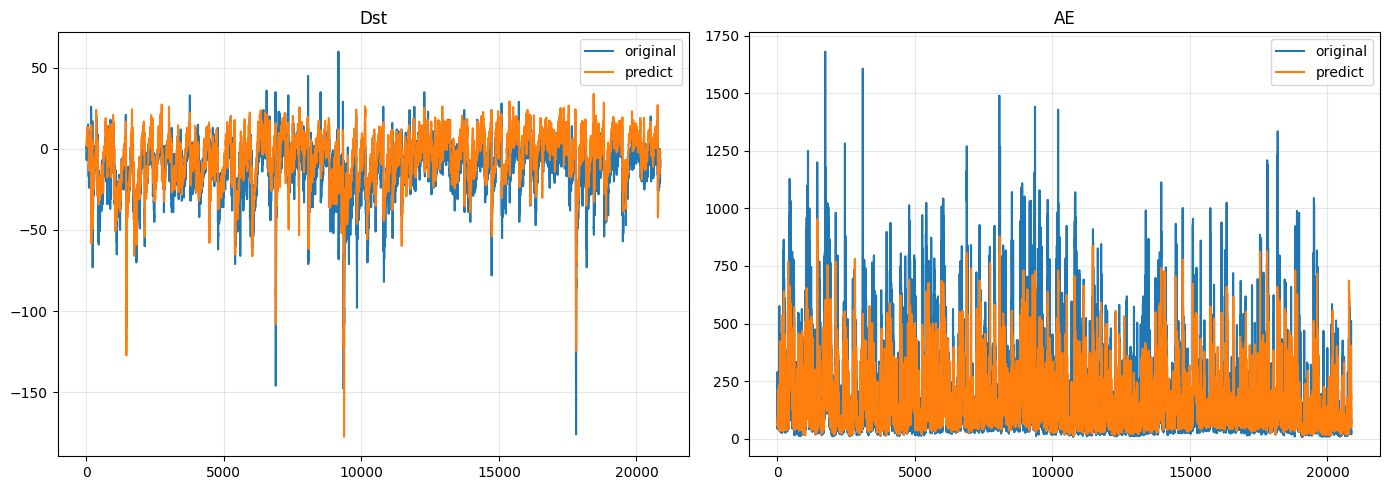

In [ ]:
_, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].set_title("Dst")
axes[0].plot(dst_labels, label="original")
axes[0].plot(np.array(dst_preds), label="predict")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].set_title("AE")
axes[1].plot(ae_labels, label="original")
axes[1].plot(ae_preds, label="predict")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()